<a href="https://colab.research.google.com/github/hwangho-kim/LLM-AD/blob/master/FDC_%ED%8C%8C%EC%9A%B4%EB%8D%B0%EC%9D%B4%EC%85%98_%EB%AA%A8%EB%8D%B8_%EB%B0%8F_Few_Shot_%ED%8C%8C%EC%9D%B4%ED%94%84%EB%9D%BC%EC%9D%B8_Tansformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install fastdtw

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp312-cp312-linux_x86_64.whl size=567862 sha256=1df99719bce81c2583b56bb3f5694239aad41de982d223cc932e1e9f9586d358
  Stored in directory: /root/.cache/pip/wheels/ab/d0/26/b82cb0f49ae73e5e6bba4e8462fff2c9851d7bd2ec64f8891e
Successfully built fastdtw



[System] 현재 사용 중인 연산 디바이스: cpu

Phase 1: 데이터 생성 및 전처리 시작...
DTW를 활용하여 비동기 Trace 데이터를 기준 궤적(SEQ_LENGTH)으로 정렬 중... (병렬 가속 🚀)
-> 샘플 데이터 CSV 저장 완료 (fdc_outputs/ 폴더)
데이터 준비 완료! Pre-train: 800개, Few-shot: 20개, Test: 180개



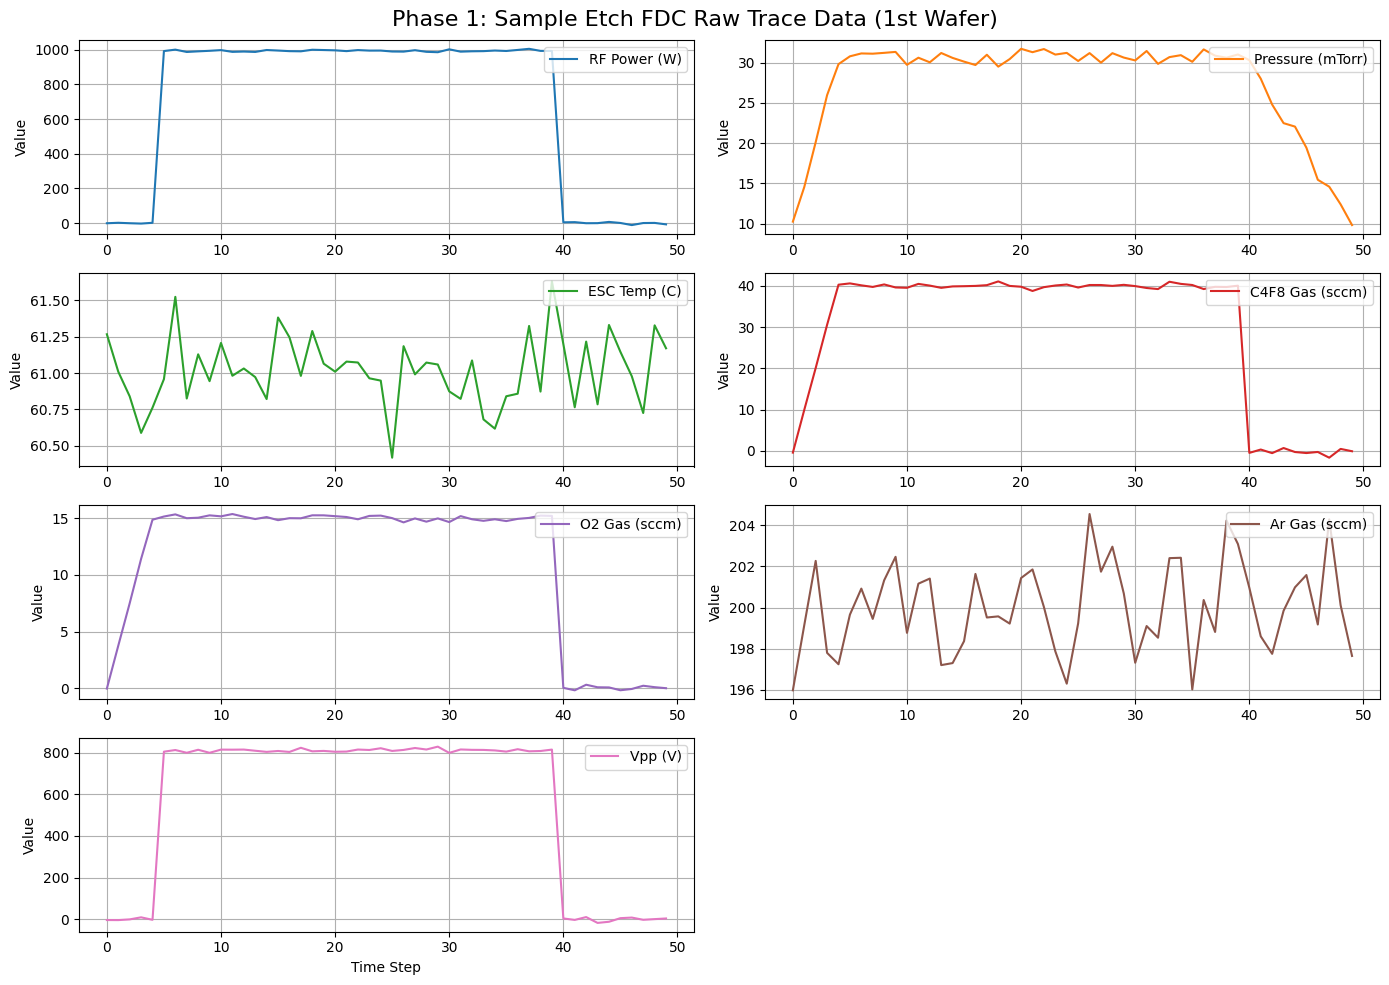

Phase 2: Foundation Model (Transformer Autoencoder) 사전 학습 시작...
-> 🏋️ 학습된 파운데이션 모델이 없습니다. 모델 학습을 진행합니다...
Pre-train Epoch [10/30], Loss: 0.1588
Pre-train Epoch [20/30], Loss: 0.1515
Pre-train Epoch [30/30], Loss: 0.1503
-> 💾 파운데이션 모델 가중치 저장 완료: fdc_outputs/foundation_model.pth

Phase 3: 소수 계측 데이터를 활용한 Foundation Model Fine-Tuning 시작...
Few-Shot Epoch [10/50], Loss: 0.0507
Few-Shot Epoch [20/50], Loss: 0.0437
Few-Shot Epoch [30/50], Loss: 0.0427
Few-Shot Epoch [40/50], Loss: 0.0401
Few-Shot Epoch [50/50], Loss: 0.0424
Few-Shot Fine-tuning 완료!

Phase 4: Test 데이터셋 평가 및 Dynamic Health Index 산출


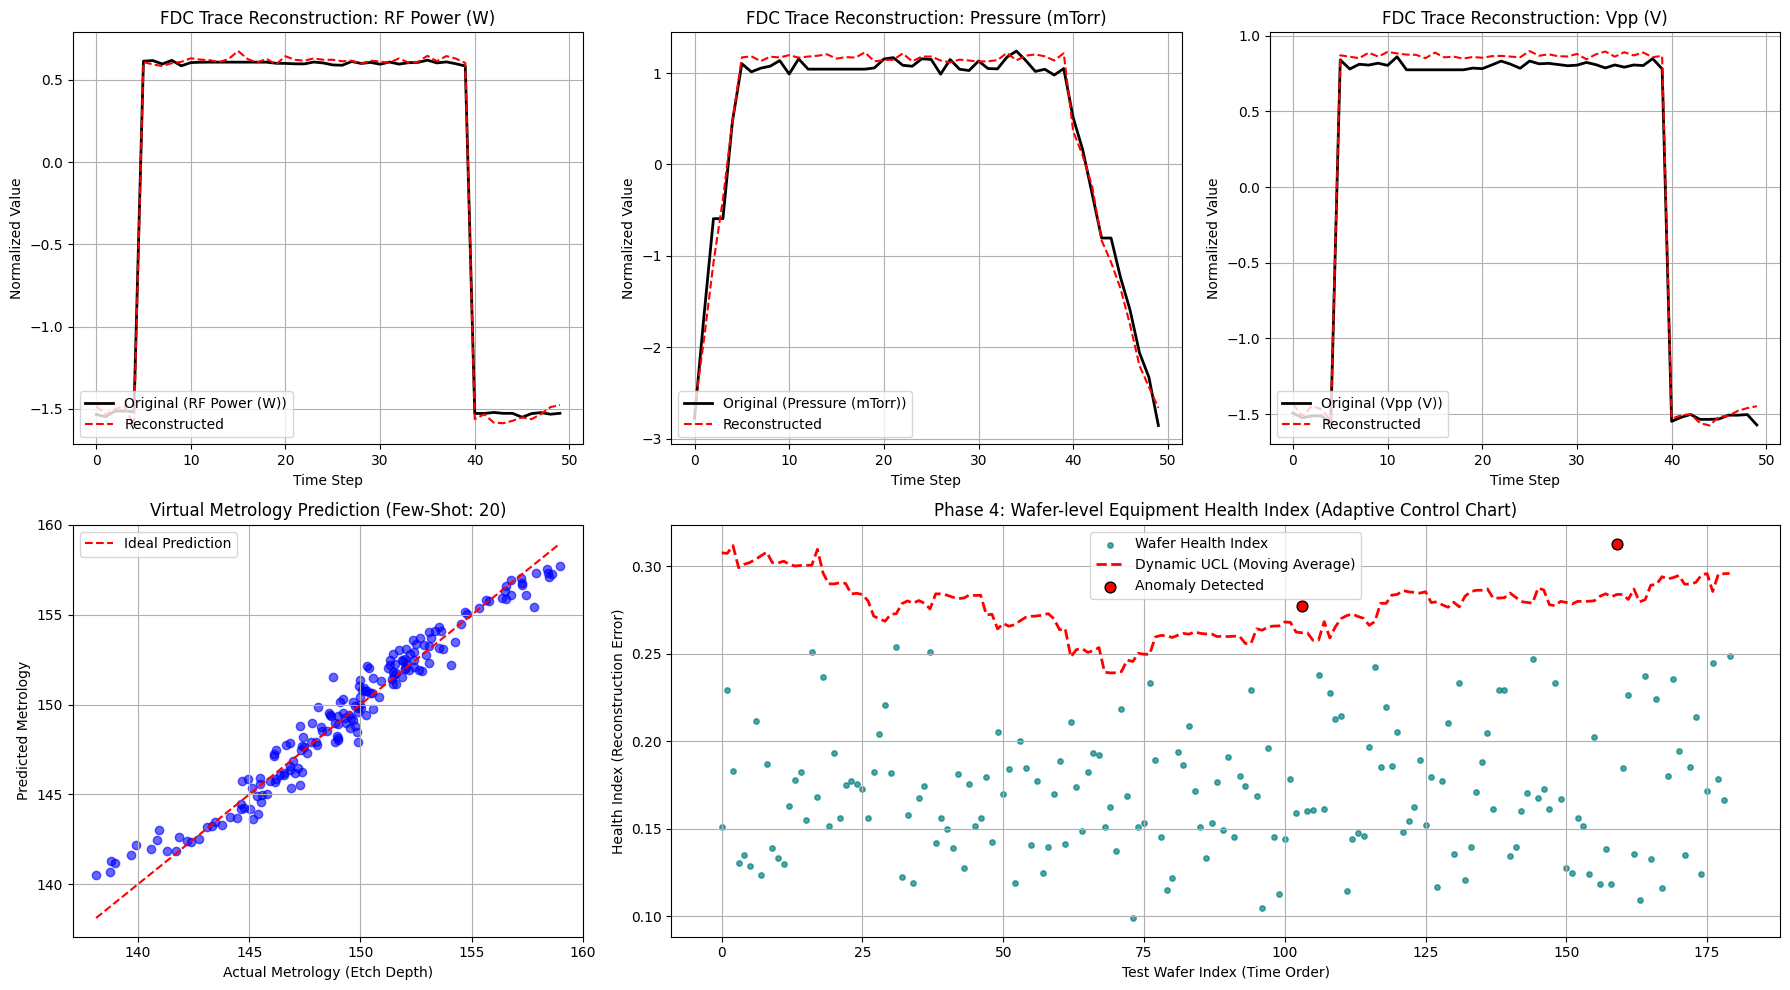

Test 세트 최종 예측 RMSE: 0.92

Phase 5: Anomaly Deep Dive & XAI (이상 원인 분석 시작)
총 2개의 이상 웨이퍼가 발견되었습니다. 모든 이상 웨이퍼에 대해 분석을 진행합니다.
이상 웨이퍼: Test Wafer #103 분석 중...


/tmp/ipykernel_12996/420585718.py:548: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


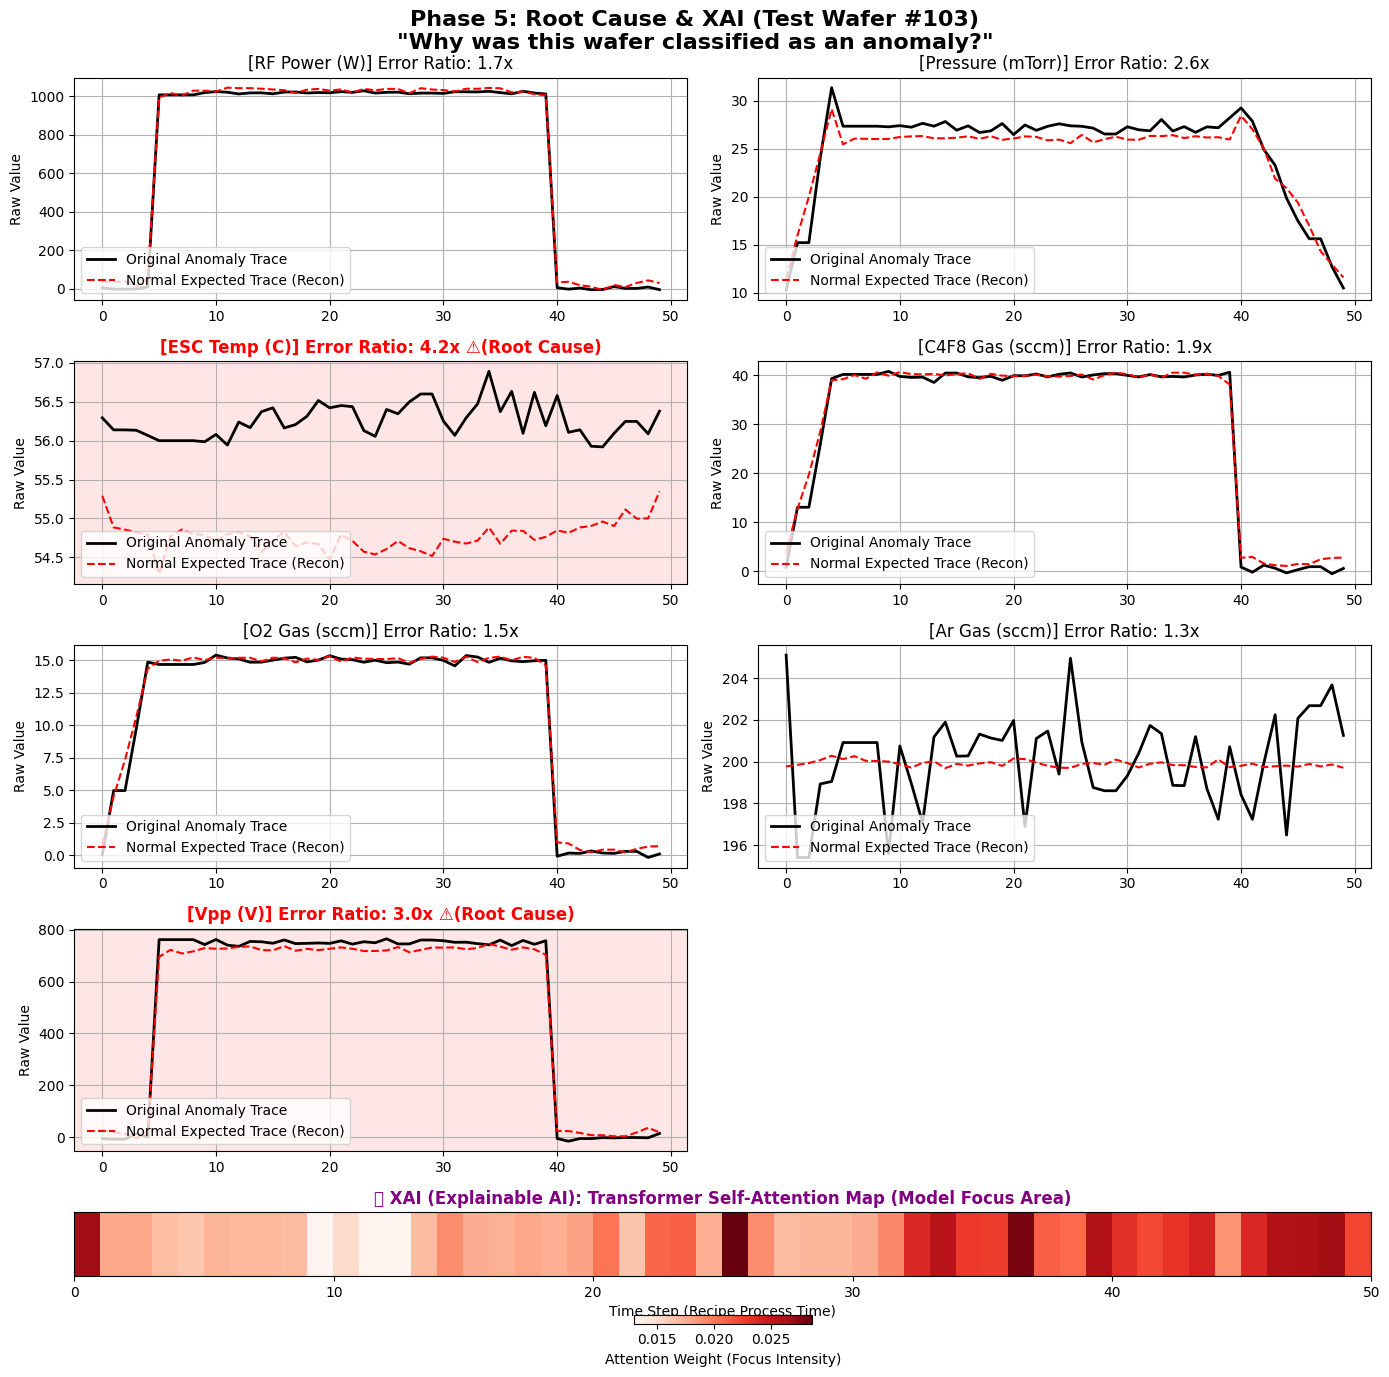


📑 [자동 진단 리포트] Test Wafer #103 불량 분석 요약
🚨 문제 원인 센서: ESC Temp (C), Vpp (V)
   -> 원인 분석: 해당 센서들의 데이터 궤적이 정상 장비의 동작 기준선(Baseline)에서 크게 이탈했습니다.
      * ESC Temp (C): 평소 정상 웨이퍼 대비 오차가 4.2배 폭증함 📈
      * Vpp (V): 평소 정상 웨이퍼 대비 오차가 3.0배 폭증함 📈

⏱️ 주요 이상 의심 시점 (AI Attention 모델의 시선):
   -> 전체 50 스텝 중 '25번째 스텝' 부근에서 비정상적인 패턴이 가장 뚜렷하게 감지되었습니다.

이상 웨이퍼: Test Wafer #159 분석 중...


/tmp/ipykernel_12996/420585718.py:548: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


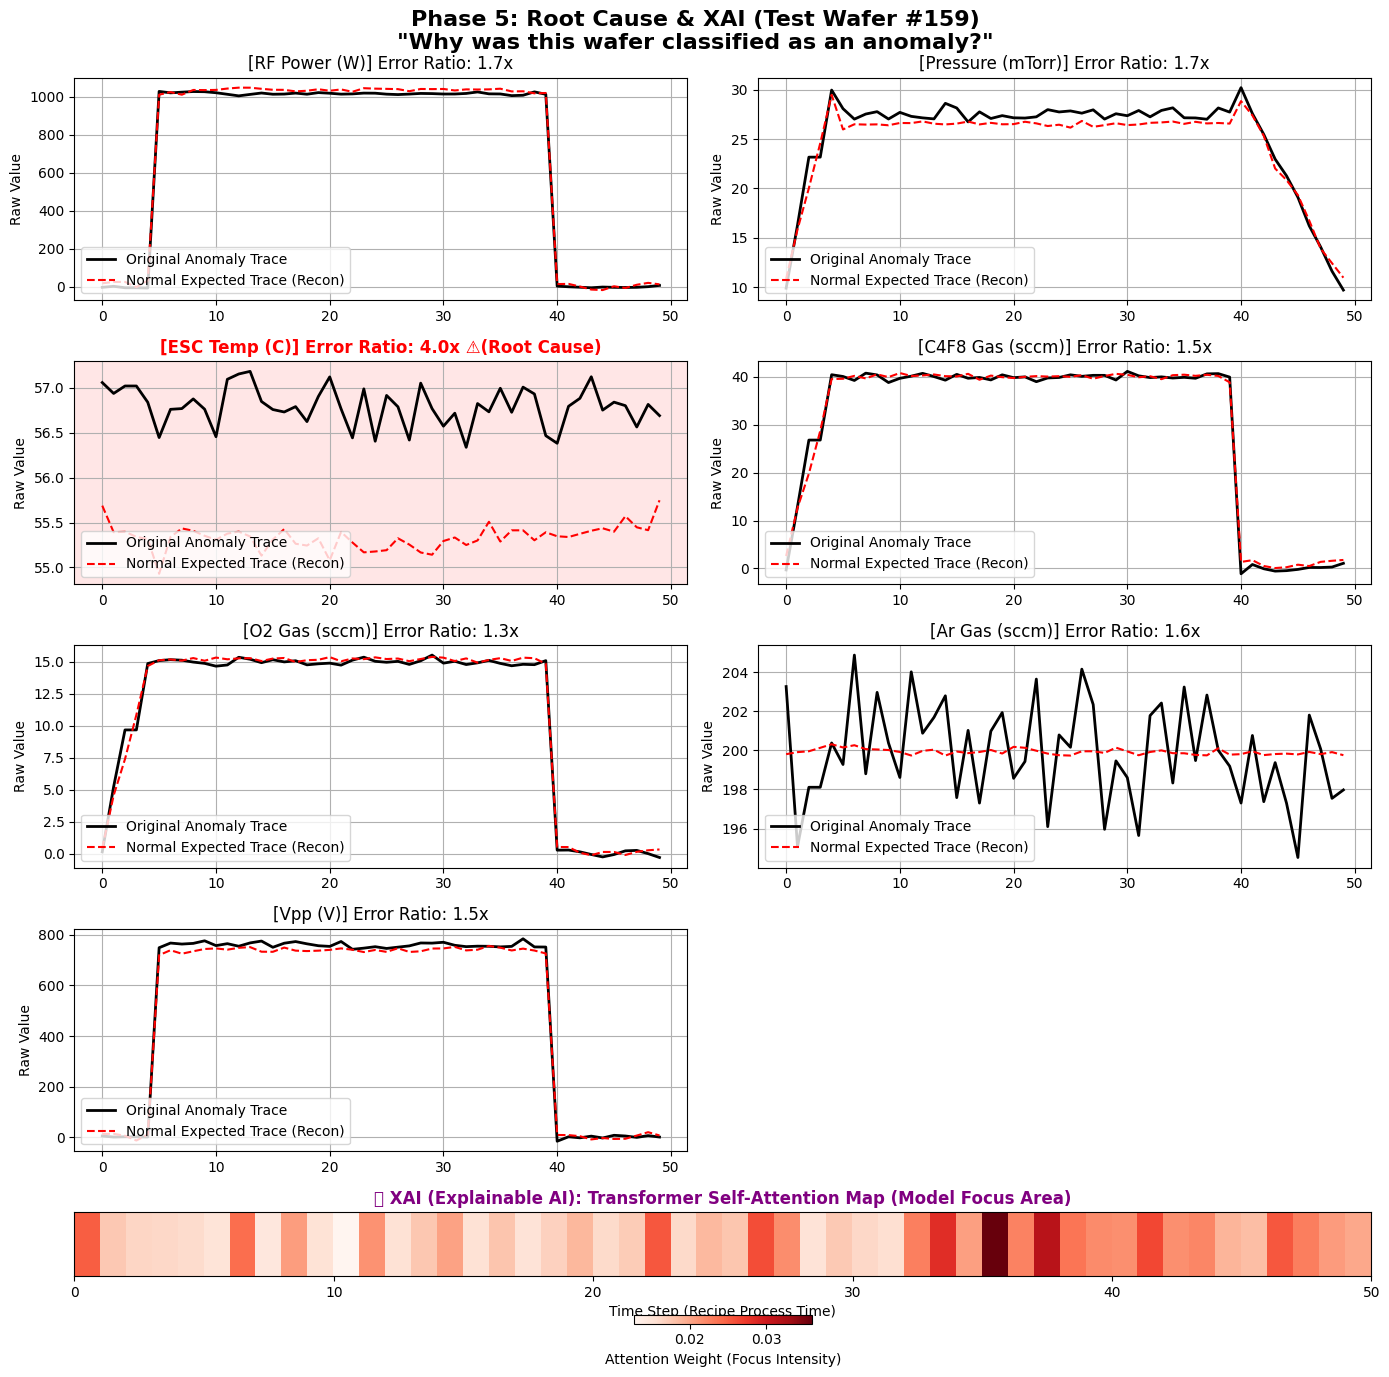


📑 [자동 진단 리포트] Test Wafer #159 불량 분석 요약
🚨 문제 원인 센서: ESC Temp (C)
   -> 원인 분석: 해당 센서들의 데이터 궤적이 정상 장비의 동작 기준선(Baseline)에서 크게 이탈했습니다.
      * ESC Temp (C): 평소 정상 웨이퍼 대비 오차가 4.0배 폭증함 📈

⏱️ 주요 이상 의심 시점 (AI Attention 모델의 시선):
   -> 전체 50 스텝 중 '35번째 스텝' 부근에서 비정상적인 패턴이 가장 뚜렷하게 감지되었습니다.



In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import os
import math
from concurrent.futures import ThreadPoolExecutor # [추가] 병렬 처리를 위한 모듈

# GPU 사용 가능 여부 체크 및 디바이스 자동 설정
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"\n[System] 현재 사용 중인 연산 디바이스: {device}\n")

# CSV 파일을 저장할 폴더 생성
output_dir = "fdc_outputs"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# ==========================================
# Phase 1: 가상 데이터 생성 및 전처리 (Data Engineering)
# ==========================================
print("Phase 1: 데이터 생성 및 전처리 시작...")

NUM_WAFERS = 1000
SEQ_LENGTH = 50
NUM_SENSORS = 7
FEW_SHOT_SIZE = 20

sensor_names = ['RF Power (W)', 'Pressure (mTorr)', 'ESC Temp (C)', 'C4F8 Gas (sccm)', 'O2 Gas (sccm)', 'Ar Gas (sccm)', 'Vpp (V)']

np.random.seed(42)
torch.manual_seed(42)

raw_X_data = []
y_data = []

for _ in range(NUM_WAFERS):
    latent_drift = np.random.randn()
    random_length = np.random.randint(40, 61)
    trace = np.zeros((random_length, NUM_SENSORS))

    step1_end = int(random_length * 0.1)
    step2_end = int(random_length * 0.8)

    trace[step1_end:step2_end, 0] = 1000 - latent_drift * 10
    trace[:step1_end, 1] = np.linspace(10, 30, step1_end)
    trace[step1_end:step2_end, 1] = 30 + latent_drift * 1.5
    trace[step2_end:, 1] = np.linspace(30, 10, random_length - step2_end)
    trace[:, 2] = 60 + latent_drift * 2
    trace[:step1_end, 3] = np.linspace(0, 40, step1_end)
    trace[step1_end:step2_end, 3] = 40
    trace[:step1_end, 4] = np.linspace(0, 15, step1_end)
    trace[step1_end:step2_end, 4] = 15
    trace[:, 5] = 200
    trace[step1_end:step2_end, 6] = 800 + latent_drift * 25

    noise_scales = [5.0, 0.5, 0.2, 0.5, 0.2, 2.0, 8.0]
    noise = np.random.randn(random_length, NUM_SENSORS) * noise_scales

    raw_X_data.append(trace + noise)

    etch_depth = 150 - latent_drift * 4.5 + np.random.randn() * 0.8
    y_data.append(etch_depth)

y_data = np.array(y_data)

# [수정] 1-2. DTW (Dynamic Time Warping) 병렬 처리 최적화
print("DTW를 활용하여 비동기 Trace 데이터를 기준 궤적(SEQ_LENGTH)으로 정렬 중... (병렬 가속 🚀)")

ref_trace = np.zeros((SEQ_LENGTH, NUM_SENSORS))
r_step1 = int(SEQ_LENGTH * 0.1)
r_step2 = int(SEQ_LENGTH * 0.8)

ref_trace[r_step1:r_step2, 0] = 1000
ref_trace[:r_step1, 1] = np.linspace(10, 30, r_step1)
ref_trace[r_step1:r_step2, 1] = 30
ref_trace[r_step2:, 1] = np.linspace(30, 10, SEQ_LENGTH - r_step2)
ref_trace[:, 2] = 60
ref_trace[:r_step1, 3] = np.linspace(0, 40, r_step1)
ref_trace[r_step1:r_step2, 3] = 40
ref_trace[:r_step1, 4] = np.linspace(0, 15, r_step1)
ref_trace[r_step1:r_step2, 4] = 15
ref_trace[:, 5] = 200
ref_trace[r_step1:r_step2, 6] = 800

def align_single_trace(raw_trace):
    """단일 Trace 데이터의 DTW 정렬을 수행하는 함수"""
    distance, path = fastdtw(ref_trace, raw_trace, dist=euclidean)
    aligned_trace = np.zeros_like(ref_trace)
    counts = np.zeros(SEQ_LENGTH)
    for ref_idx, raw_idx in path:
        aligned_trace[ref_idx] += raw_trace[raw_idx]
        counts[ref_idx] += 1
    aligned_trace = aligned_trace / counts[:, np.newaxis]
    return aligned_trace

# ThreadPoolExecutor를 통한 DTW 병렬 가속 연산
with ThreadPoolExecutor() as executor:
    X_data = list(executor.map(align_single_trace, raw_X_data))

X_data = np.array(X_data) # 비로소 모든 데이터가 Shape: (1000, 50, 7)으로 통일됨

# ==========================================
# [CSV 저장] 1 & 2: 원본 Trace 및 Metrology 데이터
# ==========================================
trace_records = []
for w_idx in range(NUM_WAFERS):
    for t_idx in range(SEQ_LENGTH):
        record = [w_idx, t_idx] + X_data[w_idx, t_idx, :].tolist()
        trace_records.append(record)
df_trace = pd.DataFrame(trace_records, columns=['Wafer_ID', 'Time_Step'] + sensor_names)
df_trace.to_csv(os.path.join(output_dir, '01_sample_fdc_trace_data.csv'), index=False)

df_metrology = pd.DataFrame({'Wafer_ID': range(NUM_WAFERS), 'Etch_Depth_nm': y_data})
df_metrology.to_csv(os.path.join(output_dir, '02_sample_metrology_data.csv'), index=False)
print(f"-> 샘플 데이터 CSV 저장 완료 ({output_dir}/ 폴더)")


# 2. 데이터 분할
X_pretrain = X_data[:800]
X_fewshot = X_data[800:800+FEW_SHOT_SIZE]
y_fewshot = y_data[800:800+FEW_SHOT_SIZE]
X_test = X_data[800+FEW_SHOT_SIZE:]
y_test = y_data[800+FEW_SHOT_SIZE:]

# 3. 데이터 정규화
scaler = StandardScaler()
X_pretrain_scaled = scaler.fit_transform(X_pretrain.reshape(-1, NUM_SENSORS)).reshape(X_pretrain.shape)
X_fewshot_scaled = scaler.transform(X_fewshot.reshape(-1, NUM_SENSORS)).reshape(X_fewshot.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, NUM_SENSORS)).reshape(X_test.shape)

y_scaler = StandardScaler()
y_fewshot_scaled = y_scaler.fit_transform(y_fewshot.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

# DataLoader 생성
train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_pretrain_scaled)), batch_size=64, shuffle=True)
fewshot_loader = DataLoader(TensorDataset(torch.FloatTensor(X_fewshot_scaled), torch.FloatTensor(y_fewshot_scaled)), batch_size=4, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test_scaled), torch.FloatTensor(y_test_scaled)), batch_size=32, shuffle=False)

print(f"데이터 준비 완료! Pre-train: {len(X_pretrain)}개, Few-shot: {len(X_fewshot)}개, Test: {len(X_test)}개\n")

# ==========================================
# [복원] Phase 1 결과 시각화 (DTW 전처리 이전의 Raw 데이터 형태 확인)
# ==========================================
fig, axs = plt.subplots(4, 2, figsize=(14, 10))
fig.suptitle('Phase 1: Sample Etch FDC Raw Trace Data (1st Wafer)', fontsize=16)
axs = axs.flatten()
for i in range(NUM_SENSORS):
    # 원본 길이가 다른 날 것 그대로의 형태 시각화
    axs[i].plot(raw_X_data[0][:, i], label=f'{sensor_names[i]}', color='C'+str(i))
    axs[i].set_ylabel('Value')
    axs[i].legend(loc='upper right')
    axs[i].grid(True)

axs[-2].set_xlabel('Time Step')
axs[-1].axis('off') # 남는 8번째 subplot 숨기기
plt.tight_layout()
plt.show()

# ==========================================
# 모델 아키텍처 정의 (Transformer with Attention XAI)
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(1), :].unsqueeze(0)
        return x

# [수정] Attention Weight(가중치)를 밖으로 추출하기 위한 커스텀 Transformer Layer
class CustomTransformerLayer(nn.Module):
    def __init__(self, d_model, nhead):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.ReLU(),
            nn.Linear(d_model * 4, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # MultiheadAttention은 (Output, Attention_Weights)를 반환함
        attn_output, attn_weights = self.self_attn(x, x, x)
        x = self.norm1(x + attn_output)
        x = self.norm2(x + self.ffn(x))
        return x, attn_weights

class FDCEncoder(nn.Module):
    """다변량 센서 데이터를 압축하고, XAI를 위한 Attention 맵을 반환하는 인코더"""
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, latent_dim=16):
        super(FDCEncoder, self).__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        # 커스텀 레이어로 모듈 리스트 구성
        self.layers = nn.ModuleList([CustomTransformerLayer(d_model, nhead) for _ in range(num_layers)])
        self.fc_latent = nn.Linear(d_model, latent_dim)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)

        # 레이어 통과 (마지막 레이어의 Attention Weight 저장)
        for layer in self.layers:
            x, attn_weights = layer(x)

        x_mean = x.mean(dim=1)
        latent = self.fc_latent(x_mean)
        return latent, attn_weights # 잠재 벡터와 Attention 히트맵 원본 반환

class FDCDecoder(nn.Module):
    """Latent Vector로부터 원래의 시계열 궤적을 복원하는 Transformer 디코더"""
    def __init__(self, latent_dim, d_model=64, nhead=4, num_layers=2, output_dim=7, seq_len=50):
        super(FDCDecoder, self).__init__()
        self.seq_len = seq_len
        self.latent_proj = nn.Linear(latent_dim, d_model * self.seq_len)
        self.pos_encoder = PositionalEncoding(d_model)

        decoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_decoder = nn.TransformerEncoder(decoder_layers, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, output_dim)

    def forward(self, latent):
        batch_size = latent.size(0)
        x = self.latent_proj(latent).view(batch_size, self.seq_len, -1)
        x = self.pos_encoder(x)
        x = self.transformer_decoder(x)
        reconstruction = self.fc_out(x)
        return reconstruction

class FDCFoundationModel(nn.Module):
    def __init__(self, input_dim=NUM_SENSORS, d_model=64, latent_dim=16, seq_len=50):
        super(FDCFoundationModel, self).__init__()
        self.encoder = FDCEncoder(input_dim, d_model=d_model, latent_dim=latent_dim)
        self.decoder = FDCDecoder(latent_dim, d_model=d_model, output_dim=input_dim, seq_len=seq_len)

    def forward(self, x):
        latent, attn_weights = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction, attn_weights # 복원 결과와 Attention 맵 반환

class FDCVirtualMetrologyModel(nn.Module):
    def __init__(self, encoder):
        super(FDCVirtualMetrologyModel, self).__init__()
        self.encoder = encoder
        self.regressor = nn.Sequential(
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        latent, _ = self.encoder(x)
        prediction = self.regressor(latent)
        return prediction.squeeze(-1)


# ==========================================
# Phase 2: Foundation Model 사전 학습 (Pre-training)
# ==========================================
print("Phase 2: Foundation Model (Transformer Autoencoder) 사전 학습 시작...")
foundation_model = FDCFoundationModel(input_dim=NUM_SENSORS).to(device)
criterion_reconstruction = nn.MSELoss()
optimizer_pretrain = optim.Adam(foundation_model.parameters(), lr=0.001)

MODEL_SAVE_PATH = os.path.join(output_dir, 'foundation_model.pth')

if os.path.exists(MODEL_SAVE_PATH):
    print(f"-> 💾 이미 학습된 파운데이션 모델을 발견했습니다. 가중치를 로드합니다: {MODEL_SAVE_PATH}")
    foundation_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
    print("-> 모델 로드 완료! (사전 학습을 건너뜁니다)\n")
else:
    print("-> 🏋️ 학습된 파운데이션 모델이 없습니다. 모델 학습을 진행합니다...")
    EPOCHS_PRETRAIN = 30
    pretrain_losses = []

    for epoch in range(EPOCHS_PRETRAIN):
        foundation_model.train()
        total_loss = 0
        for (batch_x,) in train_loader:
            batch_x = batch_x.to(device)
            optimizer_pretrain.zero_grad()
            reconstruction, _ = foundation_model(batch_x) # 튜플 언패킹
            loss = criterion_reconstruction(reconstruction, batch_x)
            loss.backward()
            optimizer_pretrain.step()
            total_loss += loss.item()

        avg_loss = total_loss/len(train_loader)
        pretrain_losses.append(avg_loss)

        if (epoch+1) % 10 == 0:
            print(f"Pre-train Epoch [{epoch+1}/{EPOCHS_PRETRAIN}], Loss: {avg_loss:.4f}")

    torch.save(foundation_model.state_dict(), MODEL_SAVE_PATH)
    print(f"-> 💾 파운데이션 모델 가중치 저장 완료: {MODEL_SAVE_PATH}\n")


# ==========================================
# Phase 3: Few-Shot Learning (미세 조정 - Fine-Tuning)
# ==========================================
print("Phase 3: 소수 계측 데이터를 활용한 Foundation Model Fine-Tuning 시작...")
vm_model = FDCVirtualMetrologyModel(encoder=foundation_model.encoder).to(device)

for param in vm_model.encoder.parameters():
    param.requires_grad = True

criterion_regression = nn.MSELoss()
optimizer_fewshot = optim.Adam([
    {'params': vm_model.encoder.parameters(), 'lr': 0.0001},
    {'params': vm_model.regressor.parameters(), 'lr': 0.01}
])

EPOCHS_FEWSHOT = 50
fewshot_losses = []

for epoch in range(EPOCHS_FEWSHOT):
    vm_model.train()
    total_loss = 0
    for batch_x, batch_y in fewshot_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer_fewshot.zero_grad()
        prediction = vm_model(batch_x)
        loss = criterion_regression(prediction, batch_y)
        loss.backward()
        optimizer_fewshot.step()
        total_loss += loss.item()

    avg_loss = total_loss/len(fewshot_loader)
    fewshot_losses.append(avg_loss)

    if (epoch+1) % 10 == 0:
        print(f"Few-Shot Epoch [{epoch+1}/{EPOCHS_FEWSHOT}], Loss: {avg_loss:.4f}")

print("Few-Shot Fine-tuning 완료!\n")


# ==========================================
# Phase 4: 평가 및 시각화 (동적 제어 한계선 Dynamic UCL)
# ==========================================
print("Phase 4: Test 데이터셋 평가 및 Dynamic Health Index 산출")
foundation_model.eval()
vm_model.eval()

train_errors = []
train_errors_per_sensor = []

with torch.no_grad():
    for (batch_x,) in train_loader:
        batch_x_dev = batch_x.to(device)
        recon, _ = foundation_model(batch_x_dev)
        recon = recon.cpu()

        mse = torch.mean((recon - batch_x)**2, dim=[1, 2]).numpy()
        train_errors.extend(mse)
        mse_sensor = torch.mean((recon - batch_x)**2, dim=1).numpy()
        train_errors_per_sensor.extend(mse_sensor)

normal_sensor_mses = np.mean(train_errors_per_sensor, axis=0)

# [수정] MLOps: Dynamic UCL (이동 평균선) 도입을 위한 히스토리 초기화
# 가장 최근 30개의 정상 데이터 오차를 바탕으로 시작
ucl_history = list(train_errors[-30:])
dynamic_ucl = []

test_predictions = []
test_actuals = []
test_health_indices = []
outliers = []
sample_original = None
sample_reconstructed = None

with torch.no_grad():
    for i, (batch_x, batch_y) in enumerate(test_loader):
        batch_x_dev = batch_x.to(device)

        reconstruction, _ = foundation_model(batch_x_dev)
        reconstruction = reconstruction.cpu()
        batch_mse = torch.mean((reconstruction - batch_x)**2, dim=[1, 2]).numpy()

        # [수정] 배치 내의 웨이퍼마다 동적 UCL 계산 및 상태 모니터링
        for mse_val in batch_mse:
            current_mean = np.mean(ucl_history)
            current_std = np.std(ucl_history)
            current_ucl = current_mean + 3 * current_std
            dynamic_ucl.append(current_ucl)

            # Anomaly 판단
            if mse_val > current_ucl:
                outliers.append(len(test_health_indices)) # 현재 웨이퍼 인덱스 추가
            else:
                # [적응형 학습] 정상적인 오차 범위 내의 데이터는 다음 UCL 계산을 위한 히스토리에 편입시킴
                ucl_history.append(mse_val)
                ucl_history.pop(0)

            test_health_indices.append(mse_val)

        if sample_original is None:
            sample_original = batch_x[0].numpy()
            sample_reconstructed = reconstruction[0].numpy()

        preds = vm_model(batch_x_dev).cpu()
        test_predictions.extend(preds.numpy())
        test_actuals.extend(batch_y.numpy())

test_predictions = y_scaler.inverse_transform(np.array(test_predictions).reshape(-1, 1)).flatten()
test_actuals = y_scaler.inverse_transform(np.array(test_actuals).reshape(-1, 1)).flatten()

# 시각화
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3, figure=fig)

# Plot 1 & 2 (Reconstruction & Metrology)
rep_sensor_indices = [0, 1, 6]
for plot_idx, sensor_idx in enumerate(rep_sensor_indices):
    ax = fig.add_subplot(gs[0, plot_idx])
    ax.plot(sample_original[:, sensor_idx], label=f'Original ({sensor_names[sensor_idx]})', color='black', linewidth=2)
    ax.plot(sample_reconstructed[:, sensor_idx], label='Reconstructed', color='red', linestyle='--')
    ax.set_title(f'FDC Trace Reconstruction: {sensor_names[sensor_idx]}')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Normalized Value')
    ax.legend(loc='lower left')
    ax.grid(True)

ax_vm = fig.add_subplot(gs[1, 0])
ax_vm.scatter(test_actuals, test_predictions, color='blue', alpha=0.6)
min_val = min(min(test_actuals), min(test_predictions))
max_val = max(max(test_actuals), max(test_predictions))
ax_vm.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Prediction')
ax_vm.set_title(f'Virtual Metrology Prediction (Few-Shot: {FEW_SHOT_SIZE})')
ax_vm.set_xlabel('Actual Metrology (Etch Depth)')
ax_vm.set_ylabel('Predicted Metrology')
ax_vm.legend()
ax_vm.grid(True)

# Plot 3: Dynamic UCL 모니터링
ax_hi = fig.add_subplot(gs[1, 1:3])
ax_hi.scatter(range(len(test_health_indices)), test_health_indices, color='teal', s=15, alpha=0.7, label='Wafer Health Index')

# [수정] 직선이 아닌 동적 제어 한계선(Dynamic UCL)을 곡선으로 플롯
ax_hi.plot(range(len(dynamic_ucl)), dynamic_ucl, color='red', linestyle='--', linewidth=2, label='Dynamic UCL (Moving Average)')

if len(outliers) > 0:
    ax_hi.scatter(outliers, np.array(test_health_indices)[outliers], color='red', s=60, zorder=5, edgecolors='black', label='Anomaly Detected')

ax_hi.set_title('Phase 4: Wafer-level Equipment Health Index (Adaptive Control Chart)')
ax_hi.set_xlabel('Test Wafer Index (Time Order)')
ax_hi.set_ylabel('Health Index (Reconstruction Error)')
ax_hi.legend()
ax_hi.grid(True)

plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean((np.array(test_actuals) - np.array(test_predictions))**2))
print(f"Test 세트 최종 예측 RMSE: {rmse:.2f}")


# ==========================================
# Phase 5: Anomaly Deep Dive (XAI & 원인 분석)
# ==========================================
print("\nPhase 5: Anomaly Deep Dive & XAI (이상 원인 분석 시작)")

if len(outliers) > 0:
    print(f"총 {len(outliers)}개의 이상 웨이퍼가 발견되었습니다. 모든 이상 웨이퍼에 대해 분석을 진행합니다.")

    for anomaly_idx in outliers:
        print(f"이상 웨이퍼: Test Wafer #{anomaly_idx} 분석 중...")

        anomaly_tensor = torch.FloatTensor(X_test_scaled[anomaly_idx]).unsqueeze(0)

        foundation_model.eval()
        with torch.no_grad():
            # [수정] 모델로부터 복원 궤적과 함께 Attention Weights(히트맵 정보) 추출
            anomaly_recon, attn_weights = foundation_model(anomaly_tensor.to(device))
            anomaly_recon = anomaly_recon.cpu()
            attn_weights = attn_weights.cpu().numpy()

        anomaly_original_np = anomaly_tensor.squeeze(0).numpy()
        anomaly_recon_np = anomaly_recon.squeeze(0).numpy()

        anomaly_sensor_mses = np.mean((anomaly_original_np - anomaly_recon_np)**2, axis=0)

        error_ratio = anomaly_sensor_mses / normal_sensor_mses
        ratio_threshold = np.mean(error_ratio) + 0.5 * np.std(error_ratio)

        raw_anomaly_original_np = scaler.inverse_transform(anomaly_original_np)
        raw_anomaly_recon_np = scaler.inverse_transform(anomaly_recon_np)

        # [수정] 시각화 레이아웃에 Attention Heatmap을 넣기 위해 GridSpec 5행 구성
        fig = plt.figure(figsize=(14, 14))
        fig.suptitle(f'Phase 5: Root Cause & XAI (Test Wafer #{anomaly_idx})\n"Why was this wafer classified as an anomaly?"', fontsize=16, fontweight='bold')
        gs = gridspec.GridSpec(5, 2, figure=fig, height_ratios=[1, 1, 1, 1, 0.5])

        axs = []
        for i in range(4):
            for j in range(2):
                if i * 2 + j < NUM_SENSORS:
                    axs.append(fig.add_subplot(gs[i, j]))

        for i in range(NUM_SENSORS):
            axs[i].plot(raw_anomaly_original_np[:, i], label='Original Anomaly Trace', color='black', linewidth=2)
            axs[i].plot(raw_anomaly_recon_np[:, i], label='Normal Expected Trace (Recon)', color='red', linestyle='--')

            is_root_cause = error_ratio[i] > ratio_threshold
            title_color = 'red' if is_root_cause else 'black'
            weight = 'bold' if is_root_cause else 'normal'

            title_text = f'[{sensor_names[i]}] Error Ratio: {error_ratio[i]:.1f}x'
            if is_root_cause:
                title_text += ' ⚠️(Root Cause)'
                axs[i].set_facecolor('#ffe6e6')

            axs[i].set_title(title_text, color=title_color, fontweight=weight)
            axs[i].set_ylabel('Raw Value')
            axs[i].legend(loc='lower left')
            axs[i].grid(True)

        # [추가] XAI: Transformer Attention Heatmap (모델이 어디를 집중해서 보았는가?)
        ax_attn = fig.add_subplot(gs[4, :])

        # attn_weights 형태: (batch, seq_len, seq_len) -> 시간별 평균 집중도 계산
        mean_attn = attn_weights[0].mean(axis=0)

        # 히트맵 그리기
        im = ax_attn.imshow(mean_attn[np.newaxis, :], cmap='Reds', aspect='auto', extent=[0, SEQ_LENGTH, 0, 1])
        ax_attn.set_title('💡 XAI (Explainable AI): Transformer Self-Attention Map (Model Focus Area)', fontweight='bold', color='purple')
        ax_attn.set_xlabel('Time Step (Recipe Process Time)')
        ax_attn.set_yticks([]) # Y축 값은 불필요하므로 제거
        fig.colorbar(im, ax=ax_attn, orientation='horizontal', fraction=0.08, pad=0.35, label='Attention Weight (Focus Intensity)')

        plt.tight_layout()
        plt.show()

        # ==========================================
        # [추가] 직관적인 자연어 기반 자동 진단 리포트 출력
        # ==========================================
        root_cause_sensors = [sensor_names[i] for i in range(NUM_SENSORS) if error_ratio[i] > ratio_threshold]
        critical_step = np.argmax(mean_attn) # 가장 Attention 집중도가 높았던 스텝 (이상 발생 의심 지점)

        print(f"\n" + "="*65)
        print(f"📑 [자동 진단 리포트] Test Wafer #{anomaly_idx} 불량 분석 요약")
        print(f"="*65)

        if root_cause_sensors:
            print(f"🚨 문제 원인 센서: {', '.join(root_cause_sensors)}")
            print(f"   -> 원인 분석: 해당 센서들의 데이터 궤적이 정상 장비의 동작 기준선(Baseline)에서 크게 이탈했습니다.")
            for rc_sensor in root_cause_sensors:
                idx = sensor_names.index(rc_sensor)
                print(f"      * {rc_sensor}: 평소 정상 웨이퍼 대비 오차가 {error_ratio[idx]:.1f}배 폭증함 📈")
        else:
            print(f"🚨 문제 원인: 단일 센서의 급격한 이상보다는 전체적인 파형 밸런스가 미세하게 무너졌습니다.")

        print(f"\n⏱️ 주요 이상 의심 시점 (AI Attention 모델의 시선):")
        print(f"   -> 전체 {SEQ_LENGTH} 스텝 중 '{critical_step}번째 스텝' 부근에서 비정상적인 패턴이 가장 뚜렷하게 감지되었습니다.")
        print(f"="*65 + "\n")

else:
    print("UCL을 초과하는 이상 웨이퍼가 발견되지 않아 Deep Dive를 생략합니다.")